<a href="https://colab.research.google.com/github/miftahulhdd/BigData26_B_2411533005_MiftahulHudaAmri/blob/main/praktikum01/BD_B_P01_2411533005_MiftahulHudaAmri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sys, platform, multiprocessing

print("python :", sys.version.split()[0])
print("os :", platform.platform())
print("cpu core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: not installed")

python : 3.13.15
os : Linux-6.6.122+-x86_64-with-glibc2.39
cpu core : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [6]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       8.4Gi       2.2Mi       3.3Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [7]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


In [8]:
import time, os, psutil

proses = psutil.Process(os.getpid())

catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024 ** 2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik :.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [9]:
import urllib.request

URL =("https://d37ci6vzurychx.cloudfront.net/trip-data/"
      "yellow_tripdata_2023-01.parquet")
PATH = os.path. join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024 ** 2, 1), "MB")

[unduh dataset] 1.79 s | RSS +1.7 MB
Ukuran file: 45.5 MB


In [10]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group :", meta.num_row_groups)
print("Nama kolom :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group : 1
Nama kolom : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [11]:
import pandas as pd

KOLOM = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

# bebaskan memori sebelum percobaan kedua
del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")
df.head()

[baca semua kolom] 1.27 s | RSS +500.6 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.57 s | RSS +206.6 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [12]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2     #mb per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [13]:
sebelum = df.memory_usage(deep=True).sum() / 1024 ** 2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024 ** 2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100 * (1 - sesudah / sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [14]:
df["durasi_menit"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100 * v / len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [15]:
layak = (
    (df["trip_distance"] > 0)
    & (df["trip_distance"] < 100)
    & df["durasi_menit"].between(1, 180)
    & (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df) - len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


In [16]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 39.39 s | RSS +5.6 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [17]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 3.93 s | RSS +20.5 MB
2,986,911 baris | rata-rata total_amount = 27.33


In [18]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 18.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [19]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [20]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
         - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 6.92 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [21]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

In [22]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


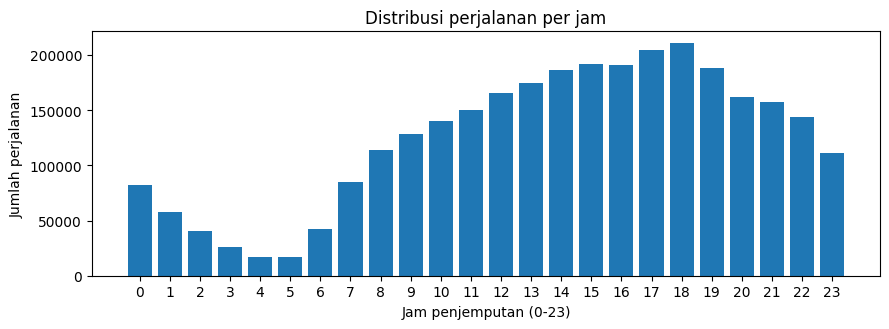

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

In [24]:
import pandas as pd

# Menyusun tabel perbandingan dari catatan kinerja
df_kinerja = pd.DataFrame(catatan)

# Menambahkan informasi tambahan atau merapikan tampilan tabel
df_kinerja.columns = ["Langkah / Metode", "Durasi (Detik)", "Pertumbuhan Memori (RSS MB)"]

display(df_kinerja)

,Langkah / Metode,Durasi (Detik),Pertumbuhan Memori (RSS MB)
0,unduh dataset,1.79,1.7
1,baca semua kolom,1.27,500.6
2,baca kolom terpilih,0.57,206.6
3,tulis CSV,39.39,5.6
4,agregasi chunking,3.93,20.5
5,spark count,6.92,0.0
6,spark agregasi,6.86,0.0


Studi Kasus

In [26]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
.groupby(["akhir_pekan", "jam"])
.agg(
    jumlah=("total_amount", "size"),
    rata_durasi=("durasi_menit", "mean"),
    rata_tarif_per_menit=("tarif_per_menit", "mean")
)
.round(2))

ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

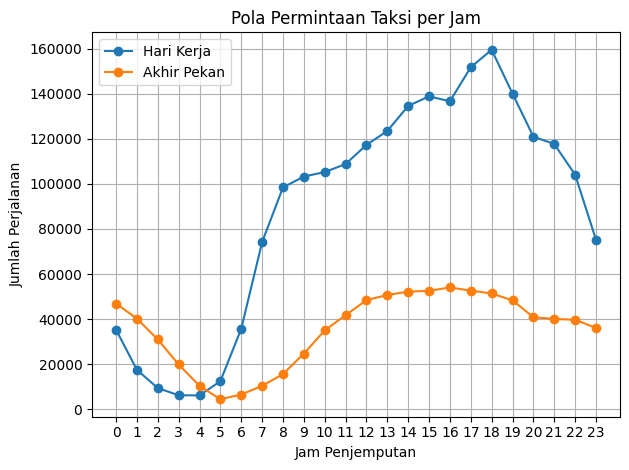

In [27]:
# grafik permintaan

import matplotlib.pyplot as plt

data_plot = ringkas.reset_index()

for status, label in [(False, "Hari Kerja"), (True, "Akhir Pekan")]:
    data = data_plot[data_plot["akhir_pekan"] == status]
    plt.plot(data["jam"], data["jumlah"], marker="o", label=label)

plt.title("Pola Permintaan Taksi per Jam")
plt.xlabel("Jam Penjemputan")
plt.ylabel("Jumlah Perjalanan")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

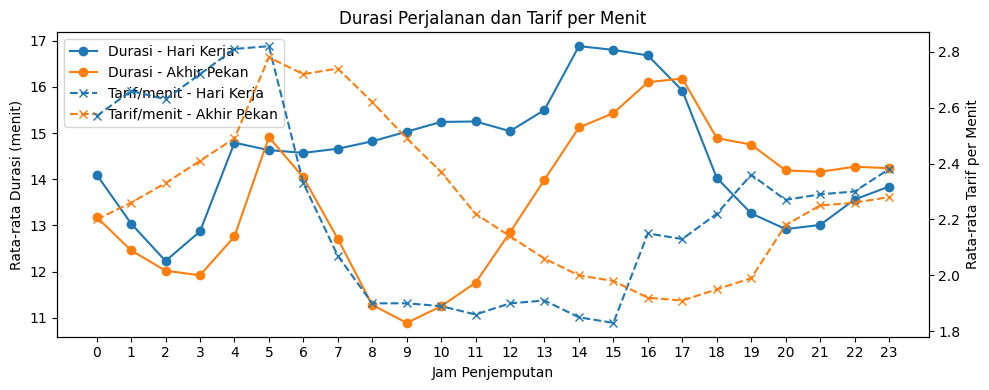

In [28]:
# grafik durasi dan tarif per menit

data_plot = ringkas.reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))

for status, label in [(False, "Hari Kerja"), (True, "Akhir Pekan")]:
    data = data_plot[data_plot["akhir_pekan"] == status]
    ax1.plot(
        data["jam"],
        data["rata_durasi"],
        marker="o",
        label=f"Durasi - {label}"
    )

ax1.set_xlabel("Jam Penjemputan")
ax1.set_ylabel("Rata-rata Durasi (menit)")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()

for status, label in [(False, "Hari Kerja"), (True, "Akhir Pekan")]:
    data = data_plot[data_plot["akhir_pekan"] == status]
    ax2.plot(
        data["jam"],
        data["rata_tarif_per_menit"],
        marker="x",
        linestyle="--",
        label=f"Tarif/menit - {label}"
    )

ax2.set_ylabel("Rata-rata Tarif per Menit")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Durasi Perjalanan dan Tarif per Menit")
plt.tight_layout()
plt.show()

Latihan

In [29]:
top5_distance = (
    bersih
    .nlargest(5, "trip_distance")
)

top5_distance

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


In [30]:
hasil_100k = ukur(
    "chunking 100.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

hasil_1m = ukur(
    "chunking 1.000.000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

[chunking 100.000] 4.09 s | RSS +54.3 MB
[chunking 1.000.000] 5.98 s | RSS +61.8 MB


In [32]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] != 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    np.nan
)

rata_persen_tip = (
    bersih
    .groupby("payment_type", observed=False)["persen_tip"]
    .mean()
    .round(2)
)

rata_persen_tip

,persen_tip
payment_type,
0,20.219999
1,25.910000
2,0.000000
3,0.020000
4,0.150000


In [33]:
import time
import os

PARQUET_SNAPPY = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
PARQUET_GZIP = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

# Snappy
t0 = time.perf_counter()
bersih.to_parquet(PARQUET_SNAPPY, compression="snappy", index=False)
waktu_snappy = time.perf_counter() - t0

# Gzip
t0 = time.perf_counter()
bersih.to_parquet(PARQUET_GZIP, compression="gzip", index=False)
waktu_gzip = time.perf_counter() - t0

ukuran_snappy = os.path.getsize(PARQUET_SNAPPY) / 1024**2
ukuran_gzip = os.path.getsize(PARQUET_GZIP) / 1024**2

perbandingan_kompresi = pd.DataFrame({
    "Kompresi": ["Snappy", "Gzip"],
    "Ukuran_MB": [ukuran_snappy, ukuran_gzip],
    "Waktu_Tulis_detik": [waktu_snappy, waktu_gzip]
}).round(2)

perbandingan_kompresi

,Kompresi,Ukuran_MB,Waktu_Tulis_detik
0,Snappy,63.31,2.14
1,Gzip,50.98,43.27


In [34]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("Latihan-5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

sdf_bersih = (
    spark.read.parquet(PATH)
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp("tpep_dropoff_datetime")
            - F.unix_timestamp("tpep_pickup_datetime")
        ) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
)

sdf_bersih.createOrReplaceTempView("trips_bersih")

hasil_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

hasil_pandas = (
    agregasi[["jam", "jumlah_perjalanan"]]
    .rename(columns={"jumlah_perjalanan": "jumlah"})
)

hasil_sql_pd = hasil_sql.toPandas()

perbandingan = hasil_pandas.merge(
    hasil_sql_pd,
    on="jam",
    suffixes=("_pandas", "_sql")
)

perbandingan["selisih"] = (
    perbandingan["jumlah_pandas"] - perbandingan["jumlah_sql"]
).abs()

print("Selisih maksimum:", perbandingan["selisih"].max())
perbandingan

Selisih maksimum: 0


,jam,jumlah_pandas,jumlah_sql,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0
